# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: De Casa, Samantha Claire
- _Student No._: 2023-15141
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 

![Description](Problem1_Figure1.png)

The figure is a density plot which illustrates the 2D wave interference pattern between two coherent sources originating from the point (-1, 0) and (1, 0). Each color corresponds to a value of W(x,y), allowing us to visualize the regions where the interference is constructive or destructive. As represented by the color bar in the figure, areas where the value of W(x,y) is strongly positive are more yellow, while areas where W(x,y) is strongly negative are more blue.


### Problem 2

For larger matrices, it is better to use the well-established `@` operator because it is less prone to errors and is more idiomatic. The primary flaw of the custom `matrix_multiply()` function is that it involves a large chunk of code so it is more prone to errors and is generally less efficient. Nevertheless, it is particularly useful if you're learning how matrix multiplication works. The advantage of this custom `matrix_multiply()` function over the `@` operator is that it can explicity state if matrix multiplication between two given matrices is possible in the first place. 

In general, using idiomatic Python allows us to create an algorithm that is more readable and less prone to errors. Because Python provides features that lets us express an idea concisely, we can create an algorithm that not only is easier to maintain but is also easier for other programmers to understand.

---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

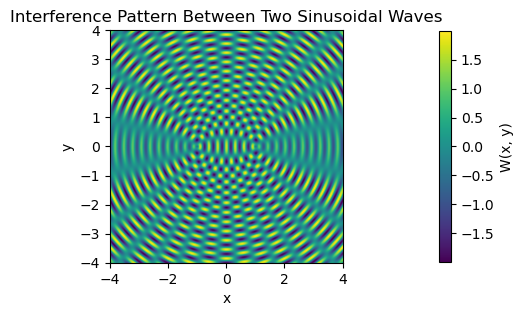

In [62]:
import matplotlib.pyplot as plt
import numpy as np

A = 1
k = 2*np.pi/0.3

r0 = np.array([-1, 0])
r1 = np.array([1, 0])

'''
the following lines create 1000 evenly spaced x- and y-values from -4 to 4
the purpose of using this any points is to make the plot appear smoother
'''
x = np.linspace(-4, 4, 1000) 
y = np.linspace(-4, 4, 1000) 

X, Y = np.meshgrid(x, y) #this line creates every possible (x, y) point combination  

'''
the following lines calculate the distance from every point (x, y) to the first object r0 and 
the distance from every point (x, y) to the second object r1
'''
R0 = np.sqrt((X - r0[0])**2 + (Y - r0[1])**2) #on the given equation, this corresponds to the absolute value of r-r0 
R1 = np.sqrt((X - r1[0])**2 + (Y - r1[1])**2) #on the given equation, this corresponds to the absolute value of r-r1

W = A*np.sin(k*R0) + 1*np.sin(k*R1) #this is the combined eﬀect of two objects dropped in a water basin

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(W, extent = [-4, 4, -4, 4]) #this plots and controls the bounding coordinates of the figure

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Interference Pattern Between Two Sinusoidal Waves')

fig.colorbar(im, pad=0.25, shrink=0.6, label="W(x, y)") #this line creates a colorbar associated with the plot
plt.savefig("Problem1_Figure1.png")
plt.show()

#### Problem 1 code summary

The purpose of the script is to visualize the wave interference pattern of two sunusoidal waves originating from different points. The algorithm is pretty straightforward. To implement this, I simply generated as many (x,y) point combinations possible within the given x and y bounds, used these values to calculate W(x, y), and then plot the result.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [1]:
import random

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [16]:
def random_integer_matrix(nrows, mcols): #this function shall create an n by m matrix
    matrix = []
    for i in range(nrows): #this line creates n sub-lists (AKA rows)
        row = []
        for i in range(mcols): #this line populates every row with m random integers from 1 to 9
            row.append(random.randint(1, 9)) 
        matrix.append(row)
    return matrix

random_integer_matrix(3, 4) #this calls the random_integer_matrix() function to create a 3x4 matrix

[[7, 5, 8, 9], [8, 7, 2, 6], [4, 4, 5, 4]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [17]:
def scalar_product(list1, list2): #this function shall return the scalar product of two row vectors
    elements_sum = 0
    for i in range(len(list1)):
        elements_product = list1[i] * list2[i] #this multiplies all elements at the same index in the two lists
        elements_sum += elements_product #this sums the product of the elements at the same index 
    return elements_sum

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [18]:
def transpose_matrix(orig_matrix): #this function shall return the transpose of an n by m matrix
    nrows = len(orig_matrix)
    mcols = len(orig_matrix[0])
    '''
    to get the transpose of a matrix, simply switch the row and column indices of all elements
    hence, the element with index [i][k] becomes the element with index [k][i]
    '''
    transposed_matrix = []
    for k in range(mcols): #this line creates m sub-lists in the transposed matrix
        new_row = []
        for i in range(nrows): 
            '''
            this section of code populates the new sub-lists 
            what I did here was to iterate through every kth element of each row in the original matrix
            and then I appended these kth element to form a new sub-list
            '''
            new_row.append(orig_matrix[i][k]) 
        transposed_matrix.append(new_row)
    return transposed_matrix

In [19]:
''' in this section, I checked if the transpose_matrix() function works '''

sample_matrix1 = random_integer_matrix(3, 4)
print(sample_matrix1)
print(transpose_matrix(sample_matrix1))

[[7, 6, 1, 8], [3, 6, 9, 7], [4, 1, 2, 5]]
[[7, 3, 4], [6, 6, 1], [1, 9, 2], [8, 7, 5]]


d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [23]:
def matrix_multiply(left_matrix, right_matrix): #this function shall perform matrix multiplication on two given matrices
    if len(left_matrix[0]) == len(right_matrix): #this condition checks if the no. of columns in the first matrix equals the no. of rows in the second matrix
        #if the condition above is satisfied, then matrix multiplication is possible so the following lines of code are executed
        '''
        matrix multiplication works by taking the scalar product of the rows of the left matrix and the columns of the right matrix
        to make this operation easier, I first took the transpose of the right matrix using the tranpose_matrix() function
        once the columns of the right matrix are converted to rows, I used the scalar_product() function to perform matrix multiplication
        '''
        transposed_right_matrix = transpose_matrix(right_matrix) #this line returns the transpose of the right matrix
        product_matrix = []
        for i in range(len(left_matrix)): #the no. of rows in the product_matrix shall be equal to the no. of columns in the left matrix
            new_row = []
            for k in range(len(transposed_right_matrix)): #the no. of columns in the product_matrix shall be equal to the no. of rows in the right matrix
                new_row.append(scalar_product(left_matrix[i], transposed_right_matrix[k])) 
            product_matrix.append(new_row)
        return product_matrix

    else: #if the condition above fails, then matrix multiplication is not possible so this line prints the following statement
        print("Matrix multiplication is not possible.")

In [24]:
''' in this section, I checked if the matrix_multiply() function works '''

sigmax = [[0, 1], [1, 0]]
sigmay = [[0, -1j], [1j, 0]]

matrix_multiply(sigmax, sigmay)

[[1j, 0j], [0j, -1j]]

In [25]:
''' in this section, I checked if the matrix_multiply() function works '''

sigmax = [[1, 0, 1], [1, 0, 1]]
sigmay = [[0, -1j], [1j, 0]]

matrix_multiply(sigmax, sigmay)

Matrix multiplication is not possible.


#### Problem 2 code summary

Since matrix multiplication is a complex operation, I employed the 'separation of concerns' principle by first creating functions that cater to every mathematical operation involved in the matrix multiplication process. When I created the `random_integer_matrix()`, `transpose_matrix()`, and `matrix_multiply()` functions, I always started the block of code with an empty list. I did this because it is easier to populate a row, and then use iteration and the `.append()` method to populate the empty list to form the matrix.

